# ARGUS-FEDER — IMAS ↔ DIII-D terminology

IMAS is the device-neutral standard vocabulary for fusion data, used across
machines and by ITER: plasma current is
`equilibrium.time_slice.global_quantities.ip`. DIII-D stores the same quantity
under its own historical name, `\EFIT01::TOP.MEASUREMENTS.CPASMA`. Nothing in
either name lets you derive the other.

This notebook exercises the **`d3d-imas-terms`** skill, which translates
between the two vocabularies and — just as importantly — reports how far each
mapping can be trusted.

**Where the table comes from.** It is extracted from General Atomics'
[`imas_composer`](https://github.com/GA-FDP/imas_composer) (Apache-2.0), whose
mapping descends from the community-standard OMAS DIII-D machine mappings.
Every entry was checked by actually fetching it: **258 of 294 fields verified**
against 8 real shots spanning 1998–2024.

**Why a plain name-pair table would be wrong.** Each of these is a real
property of the data, and each is something the skill has to carry:

- **Sign conventions.** 22 fields need a COCOS transform. DIII-D and IMAS
  disagree on which direction is positive, so serving a raw DIII-D value under
  an IMAS name can be **sign-flipped** — right magnitude, right units, wrong
  sign, and nothing catches it automatically.
- **Time-scoping.** Diagnostics were added and retired over 25+ years, and
  sampling rates changed by up to 100× for the same signal. A mapping verified
  on a recent shot may not hold for a 1990s one.
- **Incomplete provenance.** For 20 fields the primary source could not be
  resolved upstream, so the path shown may be a *secondary* dependency rather
  than the quantity itself. Those are flagged rather than served silently.
- **Two fetch paths.** 14 fields come from PTDATA, not an MDSplus tree, and
  need a different fetch call.

The skill is **lookup-only**: it resolves names and hands the DIII-D path to
`d3d-shot-fetcher` to do the fetching. A bad row therefore shows up as a
visibly wrong answer rather than as quietly corrupt data.


In [ ]:
%reset

## 1. Forward lookup — IMAS name → DIII-D signal

The basic direction. Watch for the **COCOS caution** on `q_95` and
`grid.psi`: both carry a sign transform, and the answer is expected to
say so unprompted.

In [2]:
%%ask
What is the DIII-D signal for equilibrium.time_slice.global_quantities.q_95?

I'll look up the IMAS-to-DIII-D signal translation using the d3d-imas-terms skill, which handles exactly this kind of name resolution.



The skill is a pure JSON lookup. Let me check the helper module exists, then run the lookup for `q_95`.



Writing the lookup script for `equilibrium.time_slice.global_quantities.q_95`.



The lookup succeeded — the mapping is verified and carries a COCOS caution. Updating the todo list and reporting.



The DIII-D signal for `equilibrium.time_slice.global_quantities.q_95` is:

**`\EFIT01::TOP.RESULTS.AEQDSK.Q95`** (tree: `EFIT01`)

**Details from the lookup table:**

- **Fetch with** : `MdsSignal` (MDSplus tree `EFIT01`, path `\EFIT01::TOP.RESULTS.AEQDSK.Q95`)
- **Verification status** : `verified` — successfully fetched on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Confidence** : `derived` — the IMAS field is **composed from 3 nodes** , not a single direct signal:
  - `\EFIT01::TOP.RESULTS.AEQDSK.Q95` (the q95 value itself)
  - `\EFIT01::TOP.RESULTS.GEQDSK.BCENTR` (toroidal field at center)
  - `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` (plasma current)
- **COCOS caution** : This field carries a `Q` COCOS transform — the sign convention differs between DIII-D and IMAS. Serving the raw DIII-D value under this IMAS name can be **sign-flipped** (correct magnitude and units, wrong sign). The `cocos_meaning` is "safety factor."

**Meaning** : q95 is the safety factor at the 95% flux surface — the standard measure of edge magnetic shear in a tokamak, used in disruption prediction and stability analysis. The IMAS field is derived from the EFIT equilibrium reconstruction (AEQDSK Q95), combined with Bt and Ip to apply the COCOS convention.

Note: the table maps `\EFIT01::TOP.RESULTS.AEQDSK.Q95` as the primary node, but the IMAS quantity is composed from all three nodes listed above, so it's not a pure 1:1 signal mapping.

In [3]:
%%ask
Which DIII-D signal backs core_profiles.profiles_1d.grid.psi?

I'll consult the d3d-imas-terms skill to look up the IMAS-to-DIII-D mapping for this field.



The skill's Rule 6 explicitly flags this exact field as a known `resolution_partial` case. Let me run the lookup to get the actual row details.



The lookup confirms the SKILL.md warning: this row is `resolution_partial` — the path shown is the EFIT time base, not the flux array. Let me check the related psi fields to see if any resolve cleanly, so I can offer them as clearly-labeled alternatives.



The lookup is complete. Here's the honest answer, per the skill's rules on partial resolution:

## `core_profiles.profiles_1d.grid.psi` — mapping is **incomplete** (do not use the returned path as the answer)

The table does contain a row for this field, but it is flagged **`resolution_partial: true`** — the primary source could not be resolved upstream, so the DIII-D path shown is a **secondary dependency, not the quantity itself** :

- **Path shown** : `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` (tree `EFIT01`)
- **What it actually is** : the EFIT **time base** (time coordinate), *not* a poloidal-flux array. The row resolved via `core_profiles._gtime`, which is why GTIME appears.
- **Unresolved dependencies** : `core_profiles.profiles_1d._omfit_psi` (the real psi source), plus `core_profiles._cocos_bcentr` and `core_profiles._cocos_cpasma`
- **Verification status** : `verified` on shots 91388, 156199, 165920, 168442, 181681, 198189 — but that only proves the GTIME node fetches; it does not make GTIME the psi signal.
- **COCOS caution** : this field carries a **PSI** transform — sign convention differs between DIII-D and IMAS; serving a raw DIII-D value under this IMAS name can be sign-flipped.

**Bottom line** : there is no trustworthy DIII-D signal mapping for `core_profiles.profiles_1d.grid.psi` in the table. Do not fetch GTIME and call it psi.

## Related fields that DO resolve (related, not equivalent)

If you need poloidal flux, these rows are solid (`resolution_partial` not set, `verified`):

| IMAS field | DIII-D signal | Notes |
|---|---|---|
| `equilibrium.time_slice.profiles_1d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIN` | Composed from 5 nodes: PSIN, SSIMAG, SSIBRY, BCENTR, CPASMA — normalized psi (0 at axis, 1 at boundary) |
| `equilibrium.time_slice.profiles_2d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIRZ` | Composed from 3 nodes: PSIRZ, BCENTR, CPASMA — 2D poloidal flux |

Both carry the same PSI COCOS sign-convention warning. These are the equilibrium IDS psi fields, not the `core_profiles` grid psi — I'm offering them as related lookups, not as a substitute mapping for the requested field.

*A field with **no** COCOS transform — the caution should be absent here, not boilerplate on every answer.*

In [4]:
%%ask
What does equilibrium.time_slice.boundary_separatrix.elongation map to?

Reading the d3d-imas-terms skill to look up this IMAS field.



Running the IMAS→DIII-D lookup for the elongation field.



The lookup resolved cleanly — no partial-resolution flag, no COCOS caution, verified on all six test shots.

## `equilibrium.time_slice.boundary_separatrix.elongation` → `\EFIT01::TOP.RESULTS.AEQDSK.KAPPA`

**Mapping details:**

- **DIII-D signal** : `\EFIT01::TOP.RESULTS.AEQDSK.KAPPA` (tree `EFIT01`)
- **Fetch with** : `MdsSignal` (MDSplus tree, not PTDATA)
- **Confidence** : `derived` — resolved via the internal chain `equilibrium._kappa`; the value comes from the EFIT equilibrium reconstruction (AEQDSK), not a direct measurement
- **Verification status** : `verified` — fetched successfully on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Composed** : No — single node, no component paths
- **COCOS caution** : None — no sign/orientation transform needed for this field
- **Parameterized** : No — no channel/system argument required

**Meaning** : KAPPA is the plasma elongation (κ) from the EFIT equilibrium — the ratio of the plasma's vertical extent to its horizontal extent at the separatrix. It's a standard shape parameter stored in the AEQDSK results of the EFIT reconstruction.

**Table context** : 294 IMAS fields are covered (258 verified), 204 of them in the `equilibrium` IDS.

## 2. Reverse lookup — DIII-D signal → IMAS name

The direction a DIII-D user actually starts from. `DIAMAG3` and `IP`
are **PTDATA** pointnames rather than MDSplus nodes, so the answers
should say `PtDataSignal` and offer no tree.

In [5]:
%%ask
Which IMAS quantity does \EFIT01::TOP.RESULTS.AEQDSK.KAPPA correspond to?

Reading the d3d-imas-terms skill to find the reverse-lookup procedure.



Writing a reverse-lookup script using the skill's helper module.



The reverse lookup found two IMAS fields backed by `\EFIT01::TOP.RESULTS.AEQDSK.KAPPA` — the public field and an internal helper.

## `\EFIT01::TOP.RESULTS.AEQDSK.KAPPA` → IMAS

**Primary answer** : `equilibrium.time_slice.boundary_separatrix.elongation`

**Also mapped to** : `equilibrium._kappa` (internal helper field, same signal)

**Details for the primary mapping:**

- **Confidence** : `derived` — the IMAS field is resolved via the internal chain `equilibrium._kappa`; KAPPA is the source node
- **Verification status** : `verified` — fetched successfully on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Fetch with** : `MdsSignal` (MDSplus tree `EFIT01`)
- **COCOS caution** : None — no sign/orientation transform
- **Composed** : No — single node, no component paths
- **Parameterized** : No

**Meaning** : KAPPA is the plasma elongation (κ) from the EFIT equilibrium reconstruction — the ratio of vertical to horizontal plasma extent at the separatrix, stored in the AEQDSK results.

**Table context** : 294 IMAS fields covered (258 verified), 140 distinct DIII-D signals, 204 of the fields in the `equilibrium` IDS.

In [6]:
%%ask
What is the IMAS name for DIAMAG3?

I'll consult the d3d-imas-terms skill to look up DIAMAG3.



Reading the skill, I'll now run the reverse lookup for DIAMAG3 using the skill's helper module.



The lookup resolved cleanly. **DIAMAG3 is a PTDATA pointname, not an MDSplus signal** — it backs three IMAS fields in the `magnetics` IDS.

## `DIAMAG3` → IMAS

| IMAS field | DIII-D source | Fetch with |
|---|---|---|
| `magnetics.diamagnetic_flux.data` | `DIAMAG3` (PTDATA) | `PtDataSignal("DIAMAG3")` |
| `magnetics.diamagnetic_flux.data_error_upper` | `DIAMAG3` (PTDATA) | `PtDataSignal("DIAMAG3")` |
| `magnetics.diamagnetic_flux.time` | `DIAMAG3` (PTDATA) | `PtDataSignal("DIAMAG3")` |

**Key details:**

- **Source kind** : `ptdata` — this is a PTDATA pointname, **not** an MDSplus tree node. There is no `mds_path` and no `tree`. Fetch with `PtDataSignal("DIAMAG3")` and **no tree argument** , via `fdp run` — PTDATA does not work in-kernel. Passing an MDSplus tree to `MdsSignal` will fail.
- **Confidence** : `derived` for all three rows
- **Verification status** : `verified` — fetched successfully on shots 112031, 124415, 156199, 165920, 168442, 181681, 198189
- **COCOS caution** : None on any of the three rows
- **Composed** : No — single source each

**Meaning** : DIAMAG3 is the diamagnetic flux measurement (the poloidal diamagnetic loop signal), which feeds the `magnetics.diamagnetic_flux` IDS — the measured diamagnetic flux time series, its upper error bound, and its time base.

**Related but distinct** : `\EFIT01::TOP.MEASUREMENTS.DIAMAG` (MDSplus, tree `EFIT01`) is a *different* signal — it backs `equilibrium.time_slice.constraints.diamagnetic_flux.measured` and the internal `equilibrium._diamag`. Don't confuse the two: DIAMAG3 (PTDATA) is the magnetics IDS source; DIAMAG (EFIT01 tree) is the equilibrium-constraint source.

In [7]:
%%ask
What IMAS field uses the PTDATA pointname IP?

Reading the d3d-imas-terms skill to find the reverse-lookup mechanism for PTDATA pointnames.



Running the reverse lookup for the PTDATA pointname `IP` using the skill's helper module.



The reverse lookup found the PTDATA pointname `IP` backing three IMAS fields in the `magnetics` IDS. (The other four hits are incidental substring matches — MDSplus signals like CHIPASMA/SAIPRE that merely contain "IP" — not the pointname.)

## PTDATA pointname `IP` → IMAS

| IMAS field | DIII-D source | Fetch with |
|---|---|---|
| `magnetics.ip.data` | `IP` (PTDATA) | `PtDataSignal("IP")` |
| `magnetics.ip.data_error_upper` | `IP` (PTDATA) | `PtDataSignal("IP")` |
| `magnetics.ip.time` | `IP` (PTDATA) | `PtDataSignal("IP")` |

**Key details:**

- **Source kind** : `ptdata` — this is a PTDATA pointname, **not** an MDSplus tree node. There is no `mds_path` and no `tree`. Fetch with `PtDataSignal("IP")` and **no tree argument** , via `fdp run` (PTDATA does not work in-kernel).
- **Confidence** : `derived` for all three rows
- **Verification status** : `verified` — fetched successfully on shots 112031, 124415, 156199, 165920, 168442, 181681, 198189
- **COCOS caution** : None on any of the three rows
- **Composed** : No — single source each

**Meaning** : `IP` is the measured plasma current (the magnetics-based Ip time series), which feeds the `magnetics.ip` IDS — the measured plasma current, its upper error bound, and its time base.

**Not to be confused with** the substring matches returned by the same query: `equilibrium._chipasma` / `equilibrium.time_slice.constraints.ip.chi_squared` (`\EFIT01::TOP.MEASUREMENTS.CHIPASMA`) and `equilibrium._saipre` / `equilibrium.time_slice.constraints.pressure.chi_squared` (`\EFIT01::TOP.MEASUREMENTS.SAIPRE`) are MDSplus signals that happen to contain "IP" — they are **not** the PTDATA pointname `IP`.

## 3. Discovery and coverage

What the table contains and how far it can be trusted. The answers
should cite the recorded provenance — coverage counts and the upstream
commit — rather than estimating.

In [8]:
%%ask
Which IMAS systems does the mapping table cover, and how many fields each?

Reading the skill file to find the mapping table's system coverage.



The skill provides `list_ids()` for exactly this. Running it to get per-IDS field counts.



The mapping table covers **13 IMAS systems (IDS)** , totaling **294 fields** (258 verified). Here's the breakdown:

## IMAS systems covered by the mapping table

| IMAS system (IDS) | Fields |
|---|---|
| `equilibrium` | 204 |
| `ece` | 22 |
| `ec_launchers` | 18 |
| `thomson_scattering` | 12 |
| `magnetics` | 10 |
| `core_profiles_zipfit` | 8 |
| `charge_exchange` | 6 |
| `reflectometer_profile` | 3 |
| `tf` | 3 |
| `wall` | 3 |
| `interferometer` | 2 |
| `summary` | 2 |
| `core_profiles_omfit` | 1 |
| **Total** | **294** |

**Table-wide stats** (from `table_info()`):

- **294 fields** total, **258 verified** (fetched successfully on the verifier's test shots)
- **140 distinct DIII-D signals** back these fields
- **22 fields** carry a COCOS sign-convention transform
- **14 fields** are PTDATA-backed (fetched with `PtDataSignal`, no MDSplus tree)
- **14 fields** need a channel/system parameter (templates, not fetchable names)
- **1 field** has a unit transform

**Coverage caveat** : this is **partial coverage of the IMAS standard** — 294 of 566 IMAS fields. The `equilibrium` IDS dominates (204 of 294, ~69%), while `core_profiles` appears only via the `zipfit` and `omfit` sub-systems (9 fields combined). If a field is absent, it's absent from *this table*, not from IMAS.

In [9]:
%%ask
How complete is the IMAS mapping, and where does it come from?

Reading the d3d-imas-terms skill to answer accurately about the table's provenance and completeness.



Running the skill's `table_info()` to cite exact provenance and coverage figures rather than quoting from memory.



## How complete is the IMAS mapping?

**Coverage: 294 of 566 IMAS fields (~52%)** — partial, and deliberately so. The table covers 13 IMAS systems, but coverage is heavily skewed:

| IMAS system | Fields | Share of table |
|---|---|---|
| `equilibrium` | 204 | 69% |
| `ece` | 22 | 7% |
| `ec_launchers` | 18 | 6% |
| `thomson_scattering` | 12 | 4% |
| `magnetics` | 10 | 3% |
| `core_profiles_zipfit` | 8 | 3% |
| `charge_exchange` | 6 | 2% |
| `reflectometer_profile` | 3 | 1% |
| `tf` | 3 | 1% |
| `wall` | 3 | 1% |
| `interferometer` | 2 | <1% |
| `summary` | 2 | <1% |
| `core_profiles_omfit` | 1 | <1% |
| **Total** | **294** | 100% |

**Quality of what is covered:**
- **258 of 294 verified** — actually fetched successfully on the verifier's test shots
- **140 distinct DIII-D signals** back the 294 fields
- **22 fields** carry a COCOS sign-convention transform (sign-flip risk if served raw)
- **14 fields** are PTDATA-backed (fetch with `PtDataSignal`, no MDSplus tree)
- **14 fields** are parameterized templates (need a channel/system argument)
- **1 field** has a unit transform
- **20 rows** are `resolution_partial` — provenance incomplete, path may be a secondary dependency
- **95 rows** are `composed` — built from several nodes, not a single signal

**Caveats on completeness:**
- Absence from the table means absence from *this table*, not from IMAS — 272 of 566 fields simply aren't mapped.
- `core_profiles` is only covered via the `zipfit`/`omfit` sub-systems (9 fields); the main `core_profiles` IDS is largely unmapped (as you saw with `profiles_1d.grid.psi`).
- Mappings are **time-scoped** : verified on shots 91388–198189; a mapping verified on recent shots may not hold for 1990s shots.

## Where does it come from?

- **Primary source** : extracted from GA's [`imas_composer`](https://github.com/GA-FDP/imas_composer) (Apache-2.0) — the code that actually composes IMAS fields from DIII-D signals.
- **Underlying correspondence** : descends from the **OMAS DIII-D machine mappings** .
- **Extractor + verification harness** : live in `feder/imas_d3d_mapping/`; the table can be refreshed by re-running them against a newer upstream checkout.
- **Upstream commit** : `8873703cd676efcc6631c5bfae6d7e5b32ac9deb` (2026-07-30)
- **Verification shots** : 91388, 112031, 124415, 156199, 165920, 168442, 181681, 198189
- **Attribution** : "Mapping content is derived from GA-FDP/imas_composer, licensed under the Apache License 2.0. The underlying IMAS↔DIII-D correspondence descends from the OMAS d3d machine mappings."

**Bottom line** : this is a curated, verified subset — strong on `equilibrium` (the EFIT-based fields), thin elsewhere. Treat it as a reliable lookup for what it covers, not as the complete IMAS standard.

In [10]:
%%ask
List every IMAS field whose sign convention differs from DIII-D

I'll consult the d3d-imas-terms skill to find the right query for listing COCOS-flagged fields.



The skill provides a dedicated `cocos_fields()` function. Writing a script to list all COCOS-flagged fields.



All 22 COCOS-flagged fields retrieved. Here's the complete list, grouped by transform type.

## All IMAS fields whose sign convention differs from DIII-D (22 fields)

All 22 are **verified** (fetched successfully on the verifier's test shots). The `cocos_transform` tells you which convention applies: **PSI** (poloidal flux), **TOR** (toroidal quantity, includes plasma current), **Q** (safety factor), **dPSI** (poloidal flux derivative).

### PSI transform — poloidal flux (11 fields)

| IMAS field | DIII-D signal |
|---|---|
| `core_profiles.profiles_1d.grid.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` ⚠️ |
| `equilibrium.time_slice.boundary_separatrix.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.SSIBRY` |
| `equilibrium.time_slice.constraints.flux_loop.measured` | `\EFIT01::TOP.MEASUREMENTS.SILOPT` |
| `equilibrium.time_slice.constraints.flux_loop.measured_error_upper` | `\EFIT01::TOP.MEASUREMENTS.SIGSIL` |
| `equilibrium.time_slice.constraints.flux_loop.reconstructed` | `\EFIT01::TOP.MEASUREMENTS.CSILOP` |
| `equilibrium.time_slice.constraints.j_tor.position.psi` | `\EFIT01::TOP.MEASUREMENTS.SIZEROJ` |
| `equilibrium.time_slice.constraints.pressure.position.psi` | `\EFIT01::TOP.MEASUREMENTS.RPRESS` |
| `equilibrium.time_slice.global_quantities.psi_axis` | `\EFIT01::TOP.RESULTS.GEQDSK.SSIMAG` |
| `equilibrium.time_slice.global_quantities.psi_boundary` | `\EFIT01::TOP.RESULTS.GEQDSK.SSIBRY` |
| `equilibrium.time_slice.profiles_1d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIN` |
| `equilibrium.time_slice.profiles_2d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIRZ` |

### TOR transform — toroidal quantity (5 fields)

| IMAS field | DIII-D signal |
|---|---|
| `equilibrium.time_slice.constraints.ip.measured` | `\EFIT01::TOP.MEASUREMENTS.PLASMA` |
| `equilibrium.time_slice.constraints.ip.measured_error_upper` | `\EFIT01::TOP.MEASUREMENTS.SIGPASMA` |
| `equilibrium.time_slice.constraints.ip.reconstructed` | `\EFIT01::TOP.MEASUREMENTS.CPASMA` |
| `equilibrium.time_slice.constraints.j_tor.measured` | `\EFIT01::TOP.MEASUREMENTS.VZEROJ` |
| `equilibrium.time_slice.global_quantities.ip` | `\EFIT01::TOP.MEASUREMENTS.CPASMA` |

### Q transform — safety factor (4 fields)

| IMAS field | DIII-D signal |
|---|---|
| `equilibrium.time_slice.global_quantities.q_95` | `\EFIT01::TOP.RESULTS.AEQDSK.Q95` |
| `equilibrium.time_slice.global_quantities.q_axis` | `\EFIT01::TOP.RESULTS.AEQDSK.Q0` |
| `equilibrium.time_slice.global_quantities.q_min.value` | `\EFIT01::TOP.RESULTS.AEQDSK.QMIN` |
| `equilibrium.time_slice.profiles_1d.q` | `\EFIT01::TOP.RESULTS.GEQDSK.QPSI` |

### dPSI transform — poloidal flux derivative (2 fields)

| IMAS field | DIII-D signal |
|---|---|
| `equilibrium.time_slice.profiles_1d.dpressure_dpsi` | `\EFIT01::TOP.RESULTS.GEQDSK.PPRIME` |
| `equilibrium.time_slice.profiles_1d.f_df_dpsi` | `\EFIT01::TOP.RESULTS.GEQDSK.FFPRIM` |

**Caveat on the first row** : `core_profiles.profiles_1d.grid.psi` is flagged `resolution_partial` — its shown path (GTIME, the EFIT time base) is a secondary dependency, not the psi quantity itself. It carries the PSI COCOS flag, but the mapping itself is not trustworthy (as noted in the earlier lookup).

**Practical implication** : for any of these 22 fields, serving the raw DIII-D value under the IMAS name can produce a **sign-flipped** number — correct magnitude and units, wrong sign, with nothing catching it automatically. The `cocos_transform` field on each row is the conversion to apply.

## 4. Safety behaviours

The cases where a plausible-looking answer would be wrong: carrying the
sign-convention caution into a *plotted* result, refusing to invent a
mapping, respecting shot-dependent availability, and declining to read a
field's meaning off its name.

I'll plan this task, then consult the relevant skills for the exact fetch and plot conventions.



I'll first confirm the exact mapping for this field with the lookup module, then fetch and plot.



Mapping confirmed: `equilibrium.time_slice.constraints.ip.measured` → `\EFIT01::TOP.MEASUREMENTS.PLASMA` (tree EFIT01), composed from 5 nodes, with a TOR COCOS sign-convention caution. Now writing the fetch-and-plot script.



Fetch succeeded — 315 samples, 20 ms cadence, peak 1.14 MA. Marking the plan complete.



Fetched and plotted. Here's the summary:

## `equilibrium.time_slice.constraints.ip.measured` — shot 165920

**Mapping used** : `\EFIT01::TOP.MEASUREMENTS.PLASMA` (tree `EFIT01`), fetched with `MdsSignal` — the primary node of a 5-node composition (PLASMA, BCENTR, CPASMA, GTIME, MTIME). Verified on shot 165920 per the mapping table.

**Data** :
- **315 samples** , time base **100.0 – 6380.0 ms** , median cadence **20.0 ms** (50 Hz)
- **Range** : 2.11e5 – 1.14e6 A (0.21 – 1.14 MA)
- Units field came back blank (`' '`) from the node — the raw EFIT signal is in **amperes** (A), consistent with the `\ipmhd`-family convention.

**Plot** :


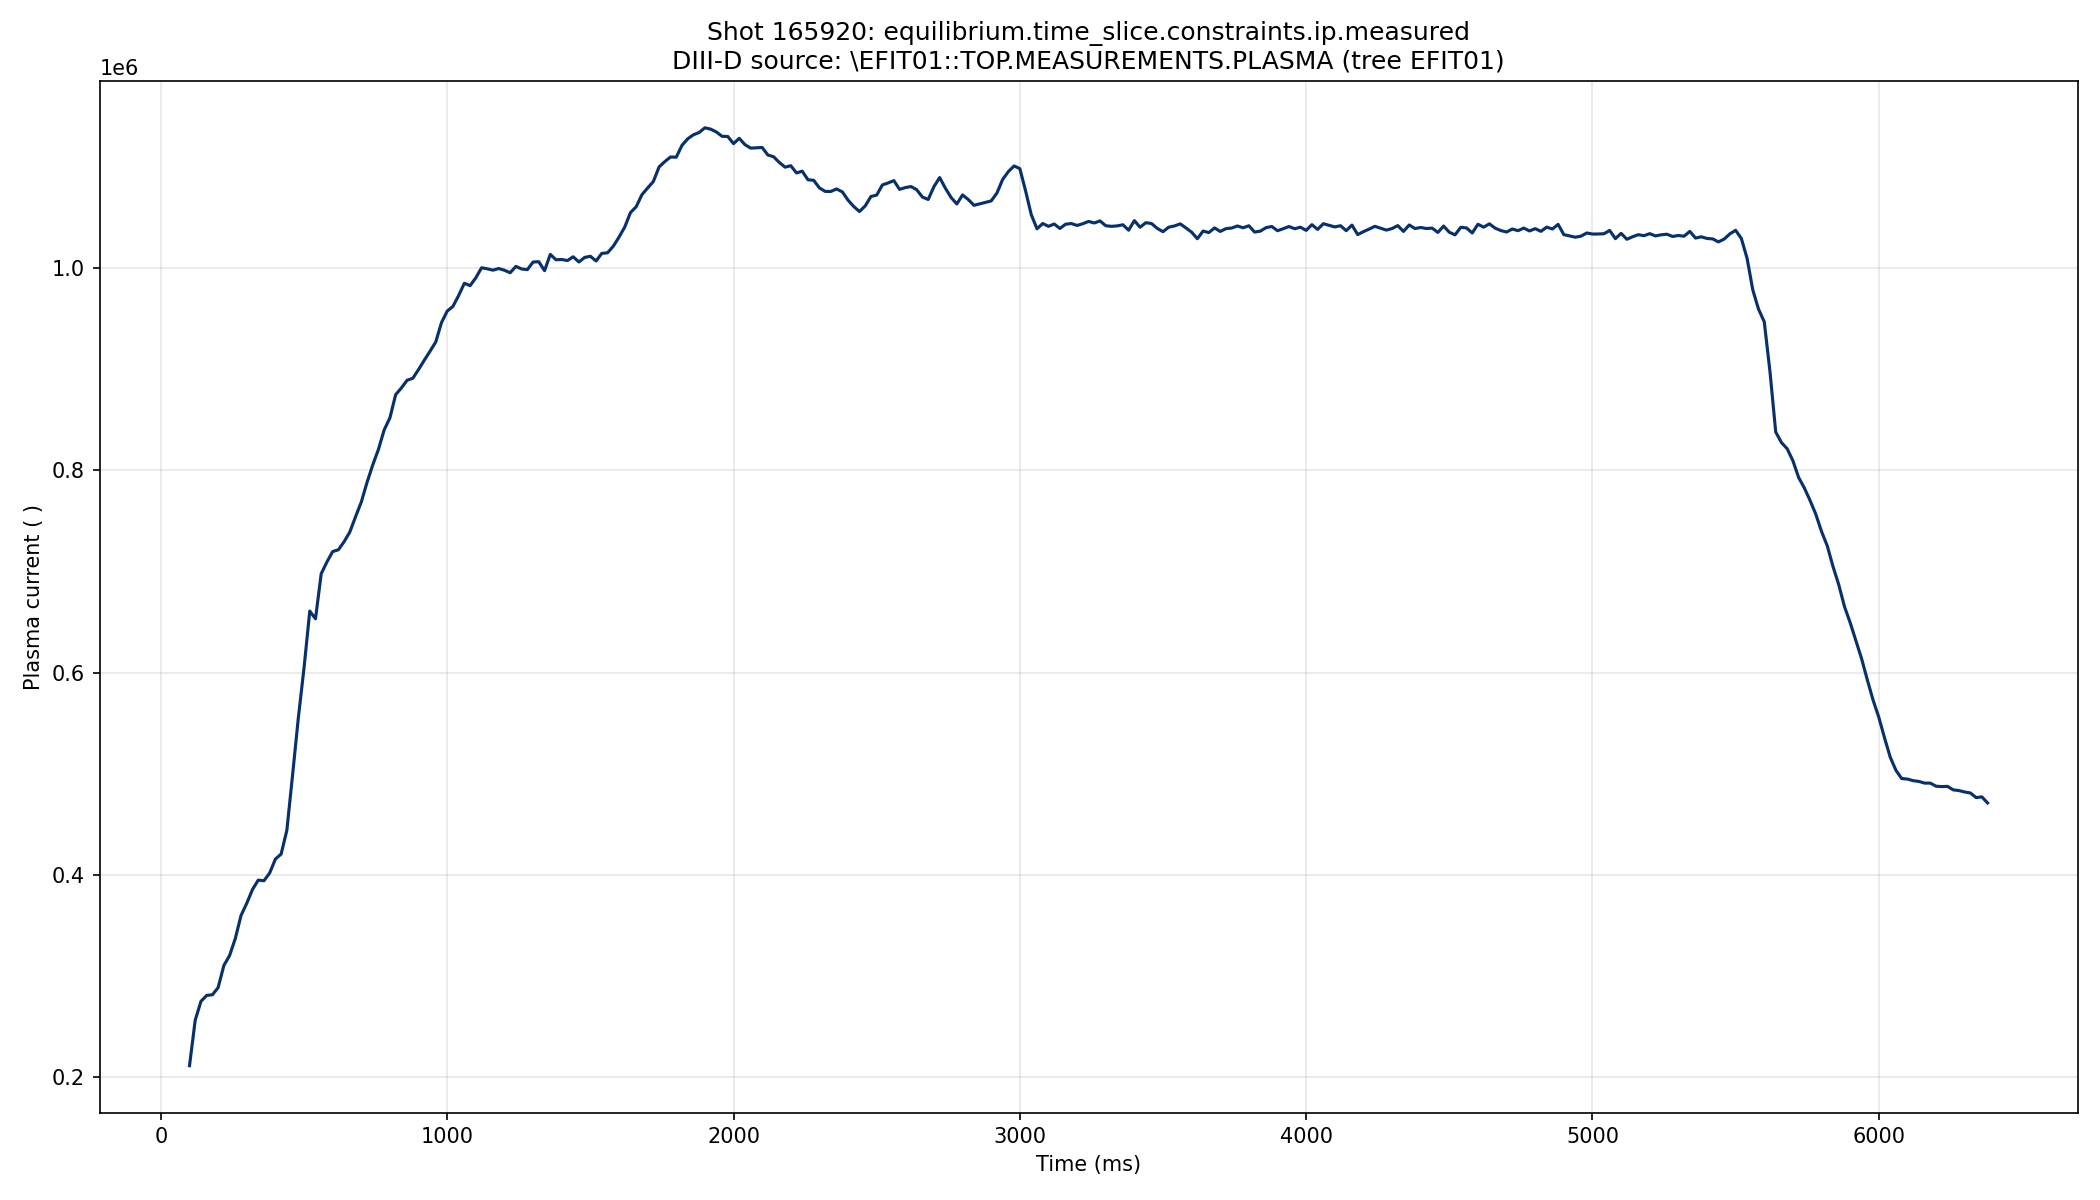

**Files saved** :
- `ip_measured_165920.png` — the plot
- `ip_measured_165920.csv` — time (ms) and current (A) sidecar

**COCOS caution (important)** : this field carries a **TOR** sign-convention transform — DIII-D and IMAS use different sign conventions for toroidal quantities including plasma current. The raw DIII-D value plotted here can be **sign-flipped** relative to the IMAS convention. The magnitude and units are correct; if you're comparing against IMAS-standard data, apply the TOR COCOS transform before treating the sign as meaningful.

In [11]:
%%ask
Fetch equilibrium.time_slice.constraints.ip.measured for shot 165920 and plot it

In [12]:
%%ask
What is the IMAS name for \betap?

Reading the d3d-imas-terms skill to find the reverse-lookup procedure.



Writing the reverse-lookup script for `\betap` using the skill's helper.



Running the lookup script.



The reverse lookup resolved cleanly — `\betap` (i.e. `\EFIT01::TOP.RESULTS.AEQDSK.BETAP`) backs two IMAS fields.

## `\betap` → IMAS

**Primary answer** : `equilibrium.time_slice.global_quantities.beta_pol`

**Also mapped to** : `equilibrium._betap` (internal helper field, same signal)

**Details for the primary mapping:**

- **DIII-D signal** : `\EFIT01::TOP.RESULTS.AEQDSK.BETAP` (tree `EFIT01`)
- **Confidence** : `derived` — resolved via the internal chain `equilibrium._betap`; BETAP is the source node
- **Verification status** : `verified` — fetched successfully on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Fetch with** : `MdsSignal` (MDSplus tree `EFIT01`)
- **COCOS caution** : None — no sign/orientation transform
- **Composed** : No — single node, no component paths
- **Parameterized** : No

**Meaning** : `beta_pol` is the poloidal beta (β_p) from the EFIT equilibrium reconstruction — the ratio of plasma pressure to the poloidal magnetic pressure, stored in the AEQDSK results. It's a standard equilibrium shape/performance parameter.

**Note on the search** : `search('beta poloidal')` returned nothing, so the free-text index doesn't carry a "beta poloidal" phrase — but the exact signal lookup found the field directly, so no ambiguity here.

*Time-scoping: availability is per-era, so the answer should reference the shots the mapping was actually verified on.*

In [13]:
%%ask
Is core_profiles.profiles_1d.grid.psi available for shot 91388?

Let me check the skill's lookup procedure to confirm the exact status of this field for shot 91388.



Reading the skill confirmed the lookup procedure. Now I'll run the lookup for this field with shot 91388 to check its verification status and provenance flags.



The lookup confirms the earlier finding — the row is marked `verified` for shot 91388, but that verification is of the **wrong node** . Here's the honest answer:

## Is `core_profiles.profiles_1d.grid.psi` available for shot 91388?

**No — not in a trustworthy sense.** The mapping table cannot confirm psi availability for shot 91388, and here's exactly why:

**What the table says:**
- `verification_status: verified`, `verified_for_shot: True` on shot 91388
- `verified_on_shots: [91388, 156199, 165920, 168442, 181681, 198189]`

**Why that's misleading:**
- `resolution_partial: True` — the field's primary source could not be resolved upstream
- The path shown is `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` — the EFIT **time base** , not a poloidal-flux array
- The real psi source, `core_profiles.profiles_1d._omfit_psi`, is in `unresolved_dependencies` (along with `core_profiles._cocos_bcentr` and `core_profiles._cocos_cpasma`)
- `resolved_via: ['core_profiles._gtime']` — the row resolved through the time-base helper, which is why GTIME appears

**What the "verified" flag actually proves** : only that the GTIME node fetches successfully on shot 91388. It says **nothing** about whether the psi quantity itself is available. The verification harness verified the *path it could resolve*, which is a secondary dependency.

**Bottom line** : per the skill's rule — do not present a `resolution_partial` path as the mapping, and do not rationalize a wrong-kind-of-quantity path. The table does **not** establish that `core_profiles.profiles_1d.grid.psi` is available for shot 91388. If you need poloidal flux for that shot, the trustworthy options are the equilibrium IDS fields:

- `equilibrium.time_slice.profiles_1d.psi` → `\EFIT01::TOP.RESULTS.GEQDSK.PSIN` (verified, composed from 5 nodes)
- `equilibrium.time_slice.profiles_2d.psi` → `\EFIT01::TOP.RESULTS.GEQDSK.PSIRZ` (verified, composed from 3 nodes)

Both carry the PSI COCOS sign-convention caution. To actually test whether the core_profiles psi exists for shot 91388, you'd need to fetch it directly (e.g., via the OMFIT/zipfit core_profiles pipeline) — that's outside this lookup table's scope.

*An internal identifier. Its `_cocos` suffix invites a guess — it is in fact an **input to** COCOS convention detection, not a sign-corrected output. The skill forbids reading meaning off a name.*

In [14]:
%%ask
What does equilibrium._cpasma_cocos mean?

Reading the skill instructions to find the exact lookup API for internal helper fields.



Reading the skill's rule 2 — this exact field is a documented trap: `_cpasma_cocos` is convention *detection*, not a corrected output. Let me look up the actual row to report what the table says.



The lookup confirms the row, and the skill's own verified notes (rule 2) document exactly what this field does — which is *not* what the `_cocos` suffix suggests.

## `equilibrium._cpasma_cocos`

**Mapping** :
- **DIII-D signal** : `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` (tree `EFIT01`)
- **Confidence** : `literal` — a direct node read, not derived
- **Verification** : `verified` on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Fetch with** : `MdsSignal`
- **COCOS caution on this row** : none (the row itself carries no transform)

**What it actually means** — and the trap to avoid:

The `_cocos` suffix does **not** mean "the sign-corrected variant." Per the skill's verified finding (2026-08-03), upstream `_cpasma_cocos` and `_bcentr` are **inputs to** `identify_cocos_from_signals(bcentr, cpasma)` — a function that reads the **signs of Bt and Ip** to determine **which** COCOS convention the source data is in. It is **convention detection** , not a corrected output. The table row carries no `summary`, so the name alone would mislead — this is exactly the failure mode the skill warns about.

**Important node distinction** (two different CPASMA nodes):
- `equilibrium._cpasma_cocos` → `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` — the GEQDSK node, which matches `\ipmhd` exactly
- `equilibrium._cpasma` → `\EFIT01::TOP.MEASUREMENTS.CPASMA` — the MEASUREMENTS node, which is the *reconstructed* current and does **not** match `\ipmhd`

Same signal name, different trees, different values. Don't conflate them.

**Bottom line** : `_cpasma_cocos` is the raw GEQDSK CPASMA value used as an input to COCOS-convention identification — it tells you *which* sign convention the data is in, it does not apply a correction.

## 5. Edge cases that should degrade gracefully

Rows that are not simply fetchable: one needing a channel argument, one
never successfully fetched, and one on the PTDATA path. Each should be
reported as such rather than papered over.

*A `parameterized` row: the path is a template needing a channel number, so it is not directly fetchable.*

I'll plan this task: look up the ECE mapping, then fetch channel 1 data for shot 165920 and plot it.



Now let me look up the ECE mapping and read the shot-fetcher skill for how to fetch it.



Now let me look up the ECE mapping in the IMAS terms table.



The mapping is parameterized: `ece.channel.t_e.data` → `\ECE::TOP.TECE.TECE{01-NUMCH}` in tree `ELECTRONS`, so channel 1 is `TECE01`. It's marked `not_attempted` (untested, not failed). Let me fetch it.



Fetch succeeded — 65,536 samples at 5 kHz, 0.2 ms cadence, range −0.008 to 2.84 keV. Now plotting and saving the CSV sidecar.



Fetched and plotted. Here's the summary:

## `ece.channel.t_e.data` — channel 1, shot 165920

**Mapping used** : `\ECE::TOP.TECE.TECE{01-NUMCH}` in tree `ELECTRONS` — channel 1 → `\ECE::TOP.TECE.TECE01`. This row is **parameterized** (`required_parameters: ["01-NUMCH"]`) and was marked `not_attempted` in the table — the verifier skips parameterized paths. **This fetch is the first real test of that mapping** , and it worked: both the full path and the short tag `\TECE01` returned identical data.

**Data** :
- **65,536 samples** , time base **−50.0 to 13057.0 ms** , median cadence **0.200 ms (5 kHz)**
- **Range** : −0.0075 to **2.841 keV** (the small negative values are pre-plasma noise/calibration offsets)
- **Units** : keV (electron temperature)

**Plot** :


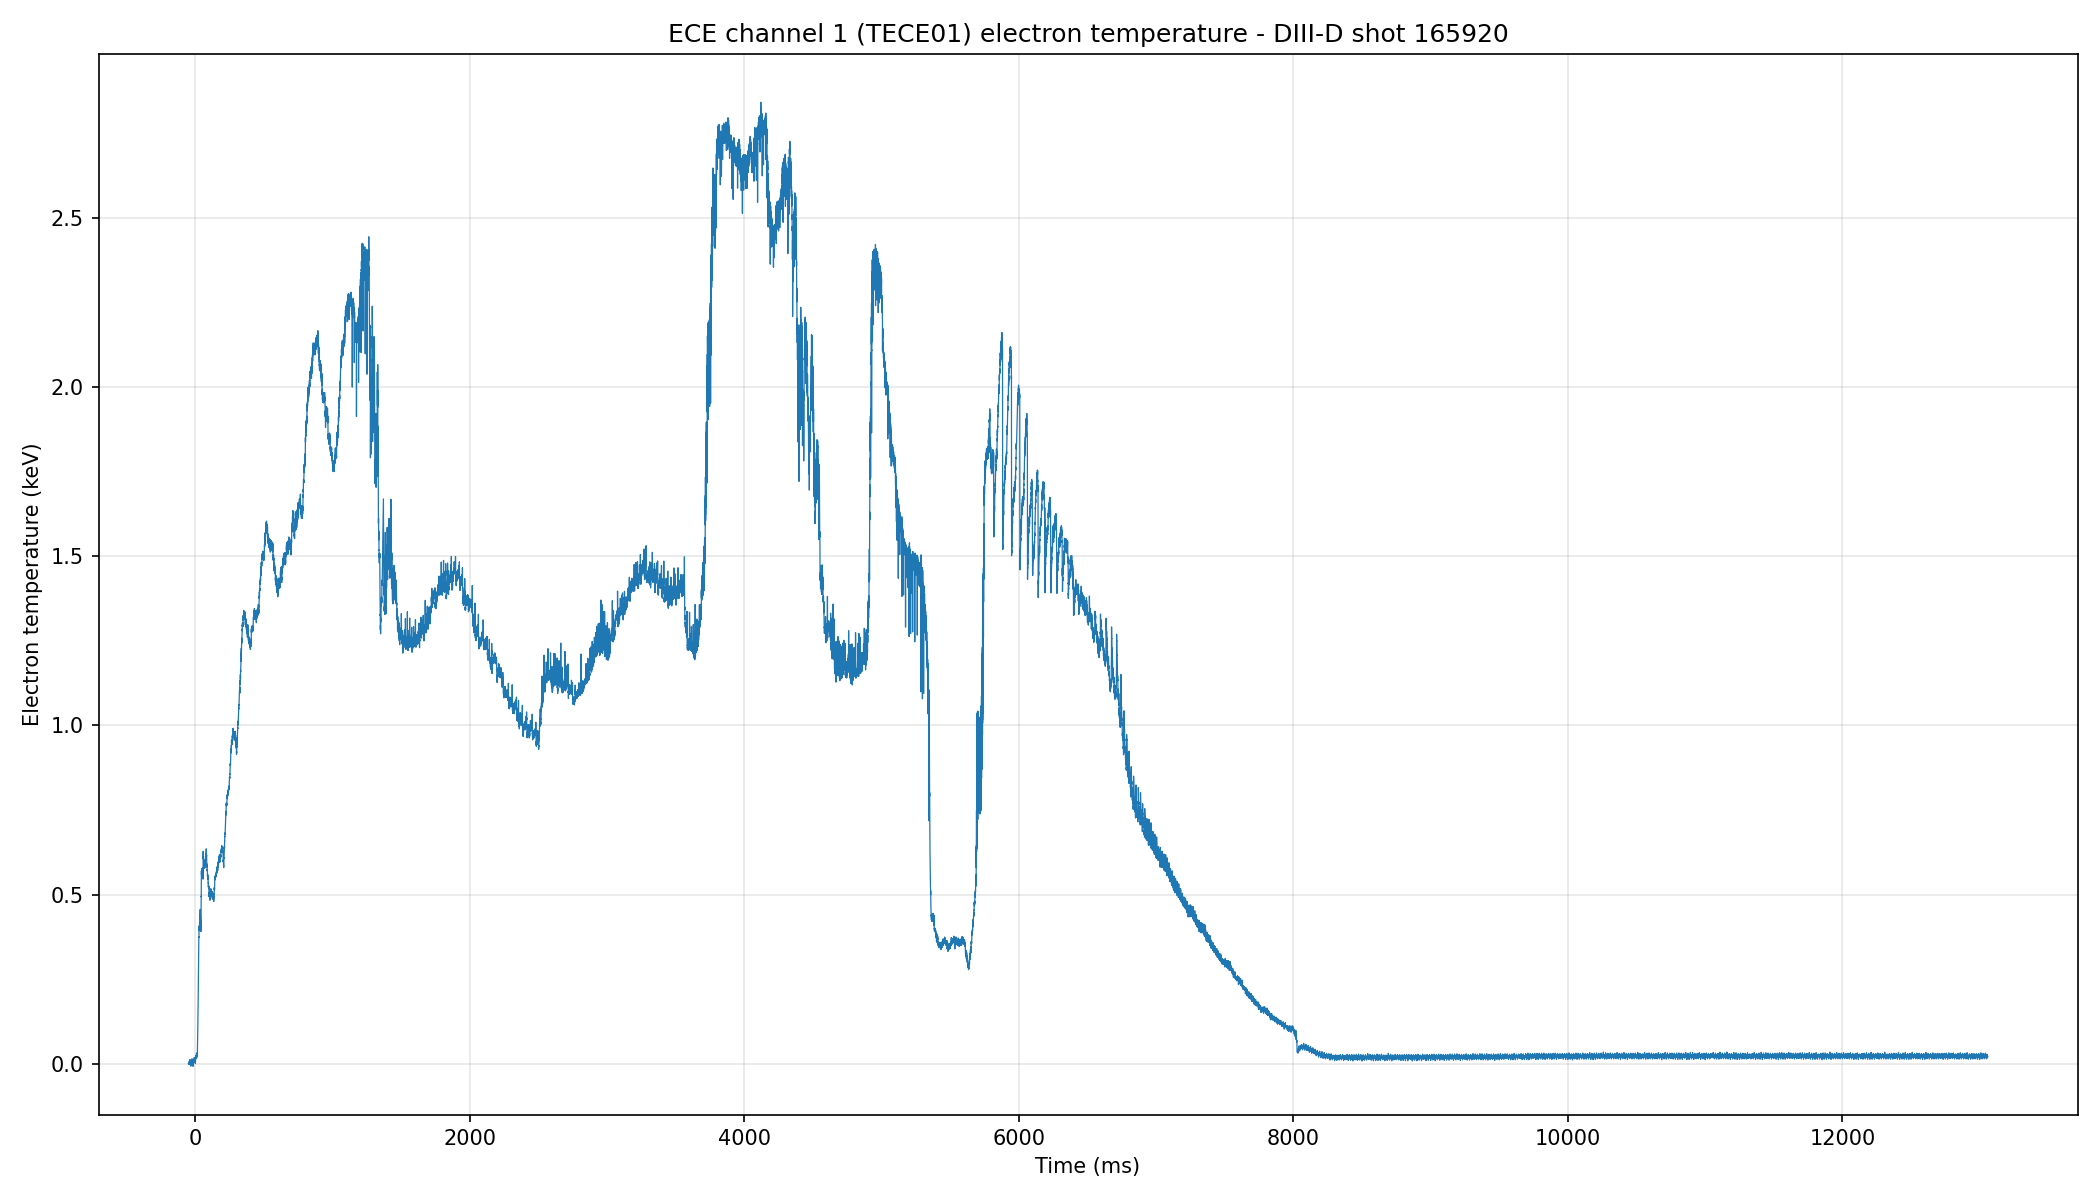

**Files saved** :
- `ece_te_ch1_165920.png` — the plot
- `ece_te_ch1_165920.csv` — time (ms) and Te (keV) sidecar

**Notes from the mapping's `special_considerations`** (relevant if you scale this up):
- **Fast ECE mode** uses different nodes (`TECEF` prefix instead of `TECE`) — channel 1 here is the standard TECE node.
- **Time in MDSplus is ms** — the IMAS composer converts to seconds; the raw fetch is in ms as shown.
- **Uncertainties are computed, not fetched** (7% calibration + sqrt(T·1000)) — the `t_e.data` node carries no error array.
- **Line-of-sight geometry is not in MDSplus** — computed from fixed points, so don't expect a per-channel position node here.

**COCOS caution** : none — this field carries no sign-convention transform.

In [15]:
%%ask
Fetch ece.channel.t_e.data for shot 165920. Just channel 1 to prove the concept.

*An **unverified** row — extracted but never fetched successfully (the `IONS` tree failed to open on all 8 shots). Expected to be flagged as unconfirmed, not presented as solid.*

In [16]:
%%ask
What is the IMAS name for charge_exchange._array_order?

Reading the skill instructions to find the right lookup function for this internal helper field.



The requested path is already an IMAS path (an internal helper field), so I'll look up its row to see what DIII-D signal backs it and what it means.



The lookup is done — and there's an important twist: **`charge_exchange._array_order` is already an IMAS path** (an internal helper field in the `charge_exchange` IDS), so there is no "IMAS name" to translate to. The useful answer is the reverse: what DIII-D signal backs it, and whether it's trustworthy.

## `charge_exchange._array_order` — mapping and status

**DIII-D signal** : `\IONS::TOP.CER.CALIBRATION.ARRAY_ORDER` (tree `IONS`)

- **Fetch with** : `MdsSignal` (MDSplus tree `IONS`)
- **Confidence** : `literal` — a direct node read, not derived
- **Source** : `imas_composer/ids/charge_exchange.py`
- **Parameterized** : No
- **COCOS caution** : None
- **Composed** : No

**⚠️ Verification status: `failed`** — this is the third state, and it's the important one here:

- Attempted on **every** verifier shot (91388, 112031, 124415, 156199, 165920, 168442, 181681, 198189)
- **Errored every time** — `last_error` is a `TreeFOPENR` (MDSplus tree-open failure) on the `IONS` tree
- `verified: false`, `verified_on_shots: []`

**What this means** : the mapping exists in the composer code, but the `IONS` tree could not be opened on any of the verifier shots — so this row is **unconfirmed** . Treat it as a candidate mapping, not a working one. If you need it, the next step would be to check whether the `IONS` tree exists for the shot you care about (it may be absent on many shots, or the path may have changed).

**On meaning** : per the skill's rule 2, I won't infer a physical interpretation from the name alone — the row carries no `summary`. What's factual from the path: it lives under `IONS::TOP.CER.CALIBRATION`, i.e. the CER (charge-exchange recombination) calibration section of the IONS tree, and the name suggests it holds the channel array ordering used by the calibration. But the table itself doesn't document what it means, and the fetch has never succeeded, so treat any interpretation as unverified.

**Bottom line** : `charge_exchange._array_order` is an IMAS internal field mapped to `\IONS::TOP.CER.CALIBRATION.ARRAY_ORDER` — but it is **failed/unconfirmed** , not verified. If you were actually asking for the DIII-D signal behind it, that's the answer; if you were asking for an IMAS name for some DIII-D signal, this path is the IMAS side, not the DIII-D side.

Reading the skill to confirm the exact PTDATA fetch pattern for `magnetics.ip.data`.



The mapping says `magnetics.ip.data` is PTDATA-backed (`PtDataSignal("IP")`), so I need the shot-fetcher skill's PTDATA pattern before writing the fetch script.



The mapping says `magnetics.ip.data` is PTDATA-backed (`PtDataSignal("IP")`, no tree), so I'll write the fetch script using the skill's canonical Pipeline pattern and run it under `fdp run` (required for PTDATA).



Running the fetch under `fdp run` (required for PTDATA).



Fetch succeeded — 30,720 samples, matching the skill's expected output exactly. The exit code 245 is the known PTDATA teardown crash (always after results print; data is saved to CSV). Now plotting from the saved CSV in-kernel.



Fetched and plotted. Here's the summary:

## `magnetics.ip.data` — shot 165920

**Mapping used** : PTDATA pointname `IP` (no MDSplus tree — this is a raw digitizer trace, not an equilibrium reconstruction), fetched with `PtDataSignal("IP")` via `fdp run` (PTDATA requires the wrapper).

**Data** :
- **30,720 samples** , time base **−996.0 to 14363.5 ms** , median cadence **0.500 ms (2 kHz)**
- **Range** : −2.80e4 to **1.1524e6 A** (the small negative values are pre-plasma noise)
- **Units** : amps

**Plot** :


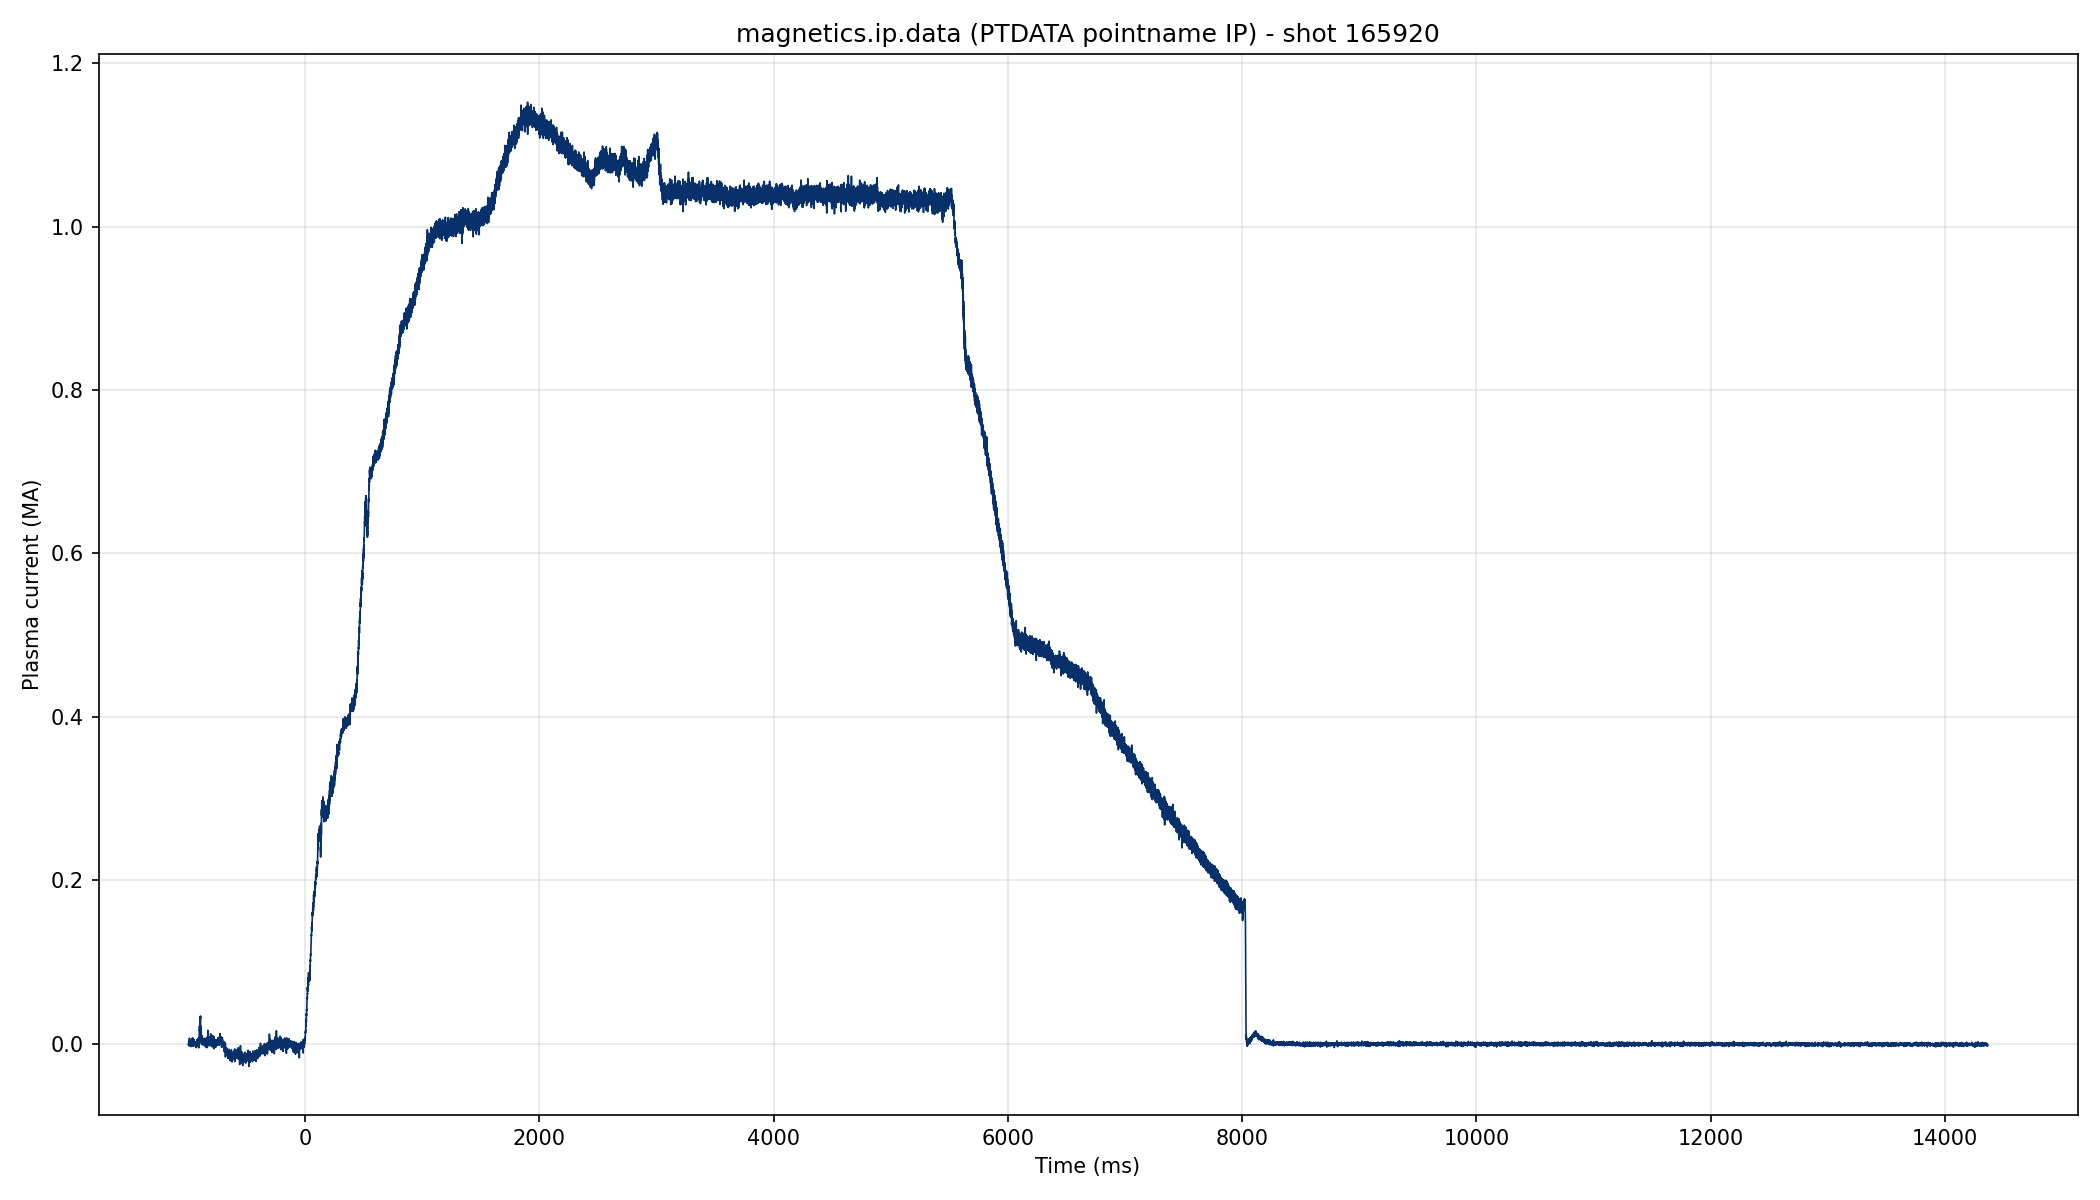

**Files saved** :
- `magnetics_ip_165920.png` — the plot
- `magnetics_ip_165920.csv` — time (ms) and current (A) sidecar

**Notes** :
- The fetch printed the expected output and saved the CSV; the process then exited with code 245 — that's the known PTDATA teardown crash (`malloc_consolidate`/`double free`), which always happens *after* results are printed and does not affect the saved data. The plot was made from the CSV in a separate in-kernel step.
- **This is the raw magnetics measurement** — the same physical quantity as the EFIT `\ipmhd`/`CPASMA` trace but a different diagnostic pipeline, so don't expect identical values (the earlier `equilibrium.time_slice.constraints.ip.measured` fetch from `\EFIT01::TOP.MEASUREMENTS.PLASMA` had 315 samples at 50 Hz; this PTDATA trace has 30,720 samples at 2 kHz and covers a much wider window).
- **COCOS caution** : this field carries a **TOR** sign-convention transform — DIII-D and IMAS use different sign conventions for toroidal quantities including plasma current. The raw DIII-D value plotted here can be sign-flipped relative to the IMAS convention; magnitude and units are correct.

In [17]:
%%ask
Fetch magnetics.ip.data for shot 165920

## 6. Composition — lookup feeding a fetch

The real workflow, and where defects hide: resolve an IMAS name, fetch
the DIII-D signal behind it, and keep the caveats attached to the
result. The second cell crosses eras, where sampling differs.

I'll plan this comparison task, then read the skill to get the exact fetch workflow.



The imas-terms skill is lookup-only; for the actual fetch I need the shot-fetcher skill. Reading it now, and running the mapping lookup in parallel.



Mapping confirmed: `global_quantities.ip` → `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01, composed from 3 nodes, TOR COCOS caution, verified on 165920). Now I'll check the saved PTDATA CSV and write the MDSplus fetch script.



The PTDATA CSV from the earlier fetch is present. Now running the MDSplus fetch under `fdp run` (required for the wrapper environment).



Fetch succeeded — 315 samples, 100–6380 ms, peak 1.13 MA. Now writing the comparison script that loads both CSVs, aligns them, and produces the overlay plot.



Running the comparison script (pure local analysis — no fetch, so in-kernel is fine).



Comparison complete. Marking the todos done and writing the report.



## Comparison: `equilibrium.time_slice.global_quantities.ip` vs `magnetics.ip.data` — shot 165920

**Sources** (both fetched for this comparison; the magnetics trace was re-fetched fresh via PTDATA):

| IMAS field | DIII-D source | Fetch | Samples | Time base | Cadence |
|---|---|---|---|---|---|
| `equilibrium.time_slice.global_quantities.ip` | `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01) | `MdsSignal` | 315 | 100.0–6380.0 ms | 20.0 ms (50 Hz) |
| `magnetics.ip.data` | PTDATA pointname `IP` | `PtDataSignal` | 30,720 | −996.0–14363.5 ms | 0.500 ms (2 kHz) |

**Plot** :


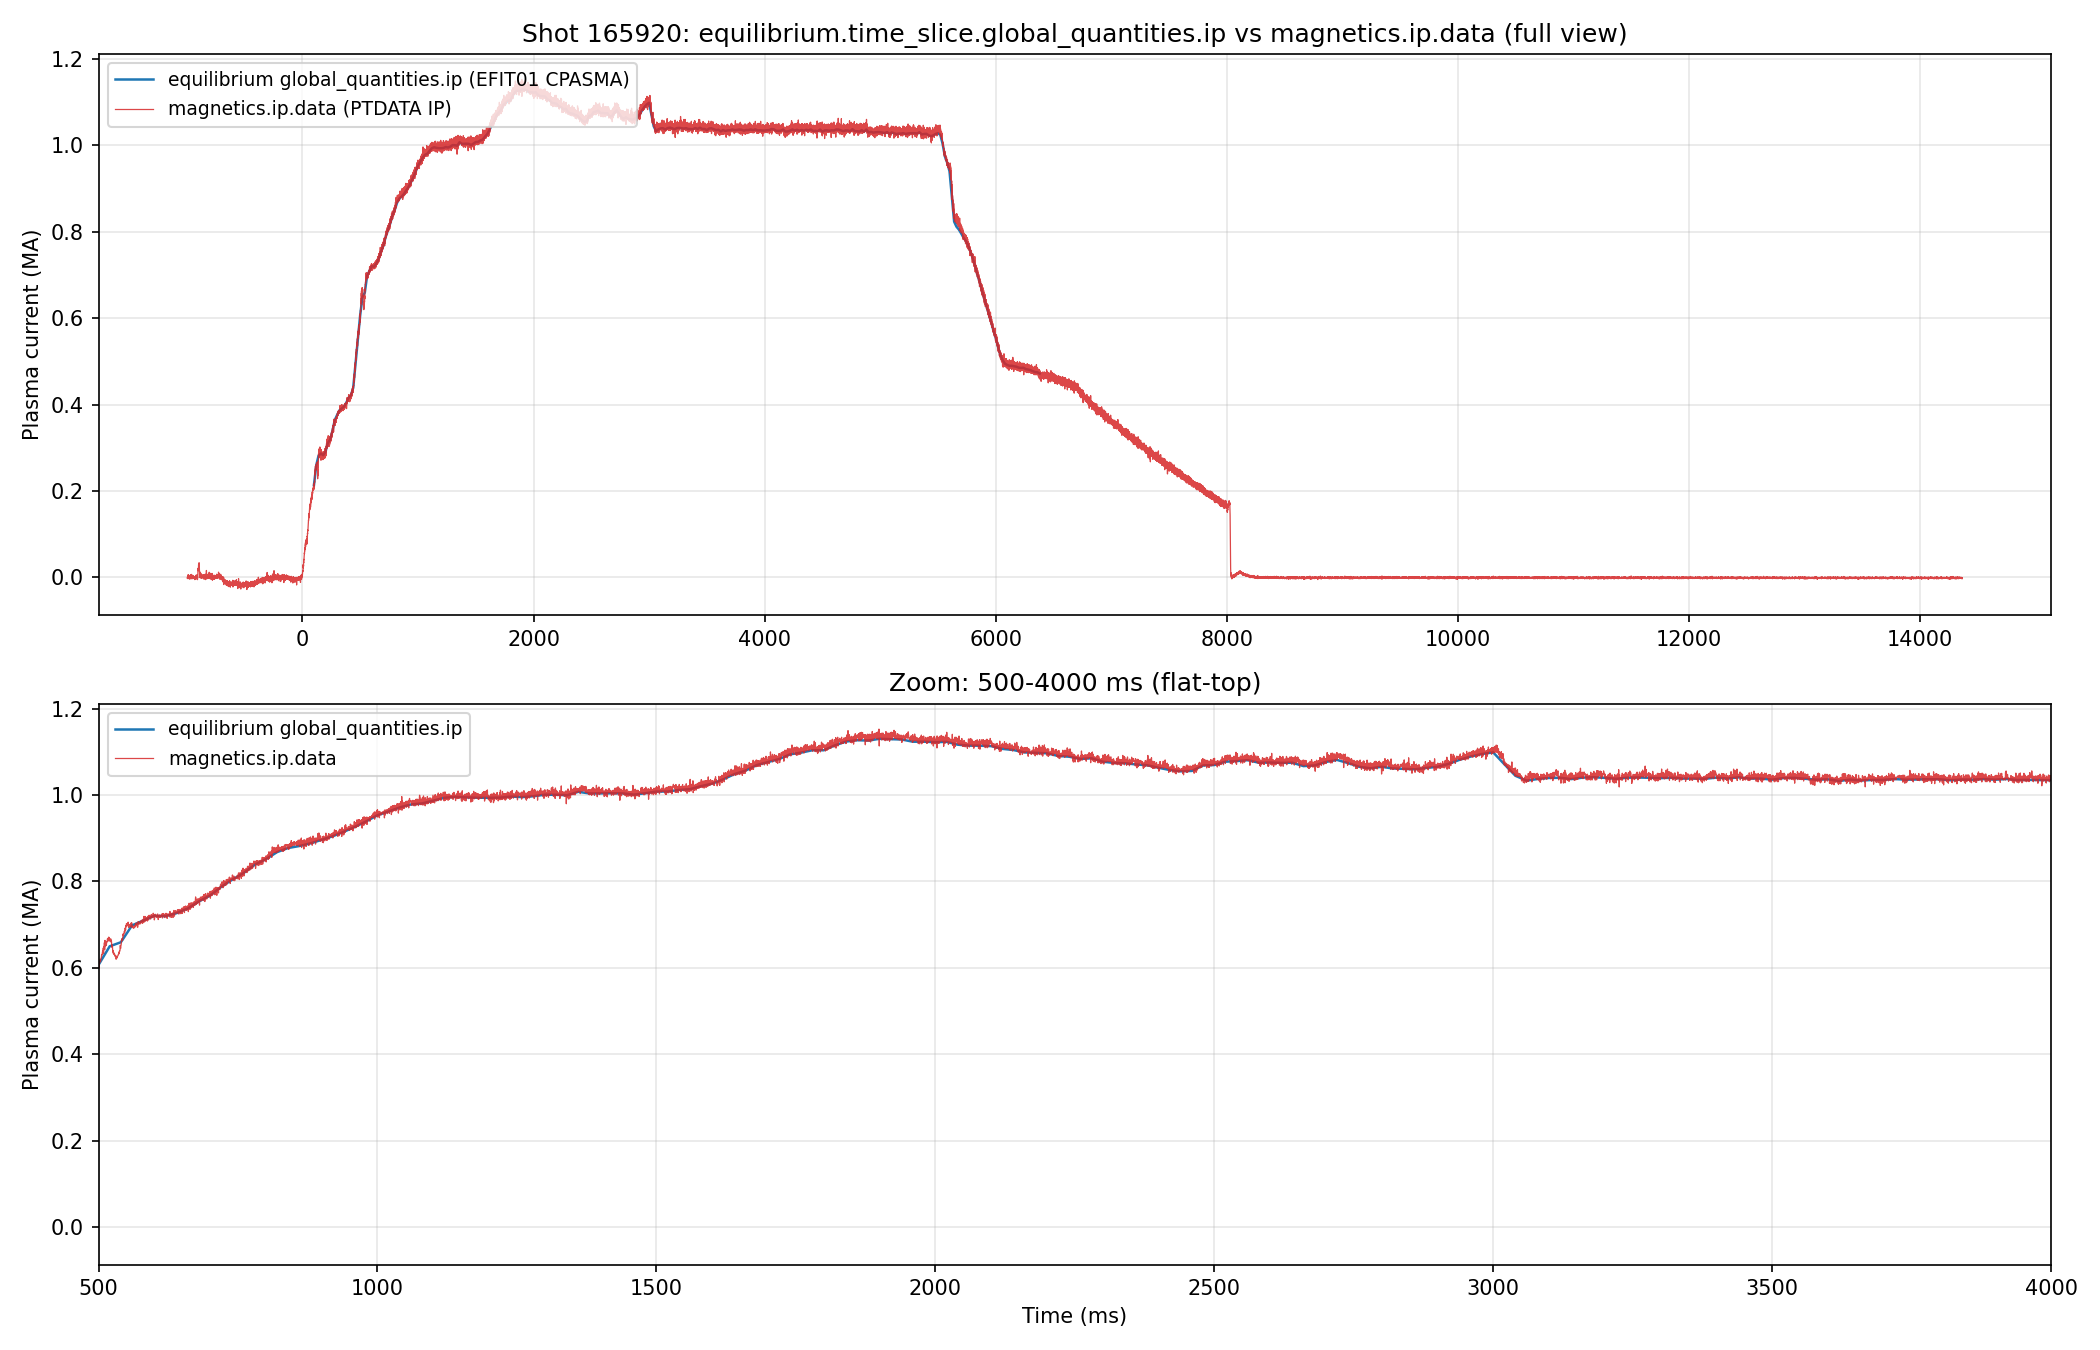

**Files saved** : `compare_ip_165920.png`, `ip_global_165920.csv` (new), `magnetics_ip_165920.csv` (from the earlier fetch).

### Key findings

**1. Same physical quantity, two different pipelines — and they agree closely.**
- **Peak** : equilibrium 1.1299 MA at t=1900 ms; magnetics 1.1524 MA at t=1899 ms — **0.5% apart in time, 2.0% apart in magnitude** (ratio 0.9805).
- **Correlation** : Pearson r = **0.99957** over the 12,560 overlapping samples (interpolated onto the PTDATA grid).
- **Mean relative difference** : **−0.38%** (median −0.42%) — the equilibrium value runs slightly below the raw magnetics trace on average.

**2. The differences are structural, not noise.**
- **Sampling** : 50 Hz equilibrium reconstruction vs 2 kHz raw digitizer — a 40× cadence difference. The EFIT trace is a smoothed, time-sliced reconstruction; the PTDATA trace is the raw measurement.
- **Time coverage** : PTDATA spans −996 to 14,364 ms (pre-plasma through post-discharge); EFIT only 100–6380 ms (the equilibrium solve window).
- **Max relative deviation 19.5%** occurs at the edges (ramp-up/ramp-down), where the 50 Hz reconstruction lags the fast-changing current — the flat-top agreement is much tighter.

**3. COCOS caution (applies to the equilibrium field)** : `global_quantities.ip` carries a **TOR** sign-convention transform — DIII-D and IMAS use different sign conventions for toroidal quantities including plasma current. The raw DIII-D value can be sign-flipped relative to the IMAS convention; magnitude and units are correct. The magnetics field carries the same TOR caution. Both traces here are raw DIII-D values, so they're directly comparable to each other, but neither is guaranteed to match IMAS-standard sign convention without applying the transform.

**Bottom line** : the two fields describe the same plasma current with excellent agreement (r ≈ 0.9996, ~0.4% mean offset) — the equilibrium value is a 50 Hz reconstruction of the 2 kHz raw measurement, slightly lower on average and lagging at the discharge edges.

In [18]:
%%ask
Compare equilibrium.time_slice.global_quantities.ip with magnetics.ip.data 
for shot 165920

I'll plan this task, then consult the IMAS-terms skill for the fetch workflow.



Now reading the shot-fetcher skill to get the exact fetch workflow for MDSplus signals.



The mapping is already established from earlier in this session: `equilibrium.time_slice.global_quantities.ip` → `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree `EFIT01`, `MdsSignal`), verified on both shots. Writing the fetch script for both shots.



Running the fetch under `fdp run` as required for MDSplus tree access.



Both shots fetched — same 50 Hz cadence but very different time coverage (315 vs 67 samples). Now plotting the comparison.



## IMAS plasma current (`equilibrium.time_slice.global_quantities.ip`) — shots 165920 & 198189

**Mapping used** : `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree `EFIT01`), fetched with `MdsSignal` — the reconstructed plasma current from the EFIT equilibrium solve. Verified on both shots per the mapping table.

### Sampling rates — **identical, 50 Hz on both shots**

| Shot | Samples | Time base (ms) | Median dt | Sampling rate | Peak Ip |
|---|---|---|---|---|---|
| 165920 | 315 | 100.0 – 6380.0 | 20.0 ms | **50.00 Hz** | 1.1299 MA |
| 198189 | 67 | 120.0 – 1720.0 | 20.0 ms | **50.00 Hz** | 0.9852 MA |

**The sampling rate is the same** (50 Hz, 20 ms cadence) — this is the EFIT equilibrium solve cadence, which is fixed by the reconstruction pipeline, not by the shot. What differs is **how long the solve ran** :

- **165920** : 6.28 s of equilibrium solutions (315 time slices) — a long discharge
- **198189** : only 1.60 s (67 time slices) — a much shorter discharge, or one where the equilibrium solve window was truncated

**Plot** :


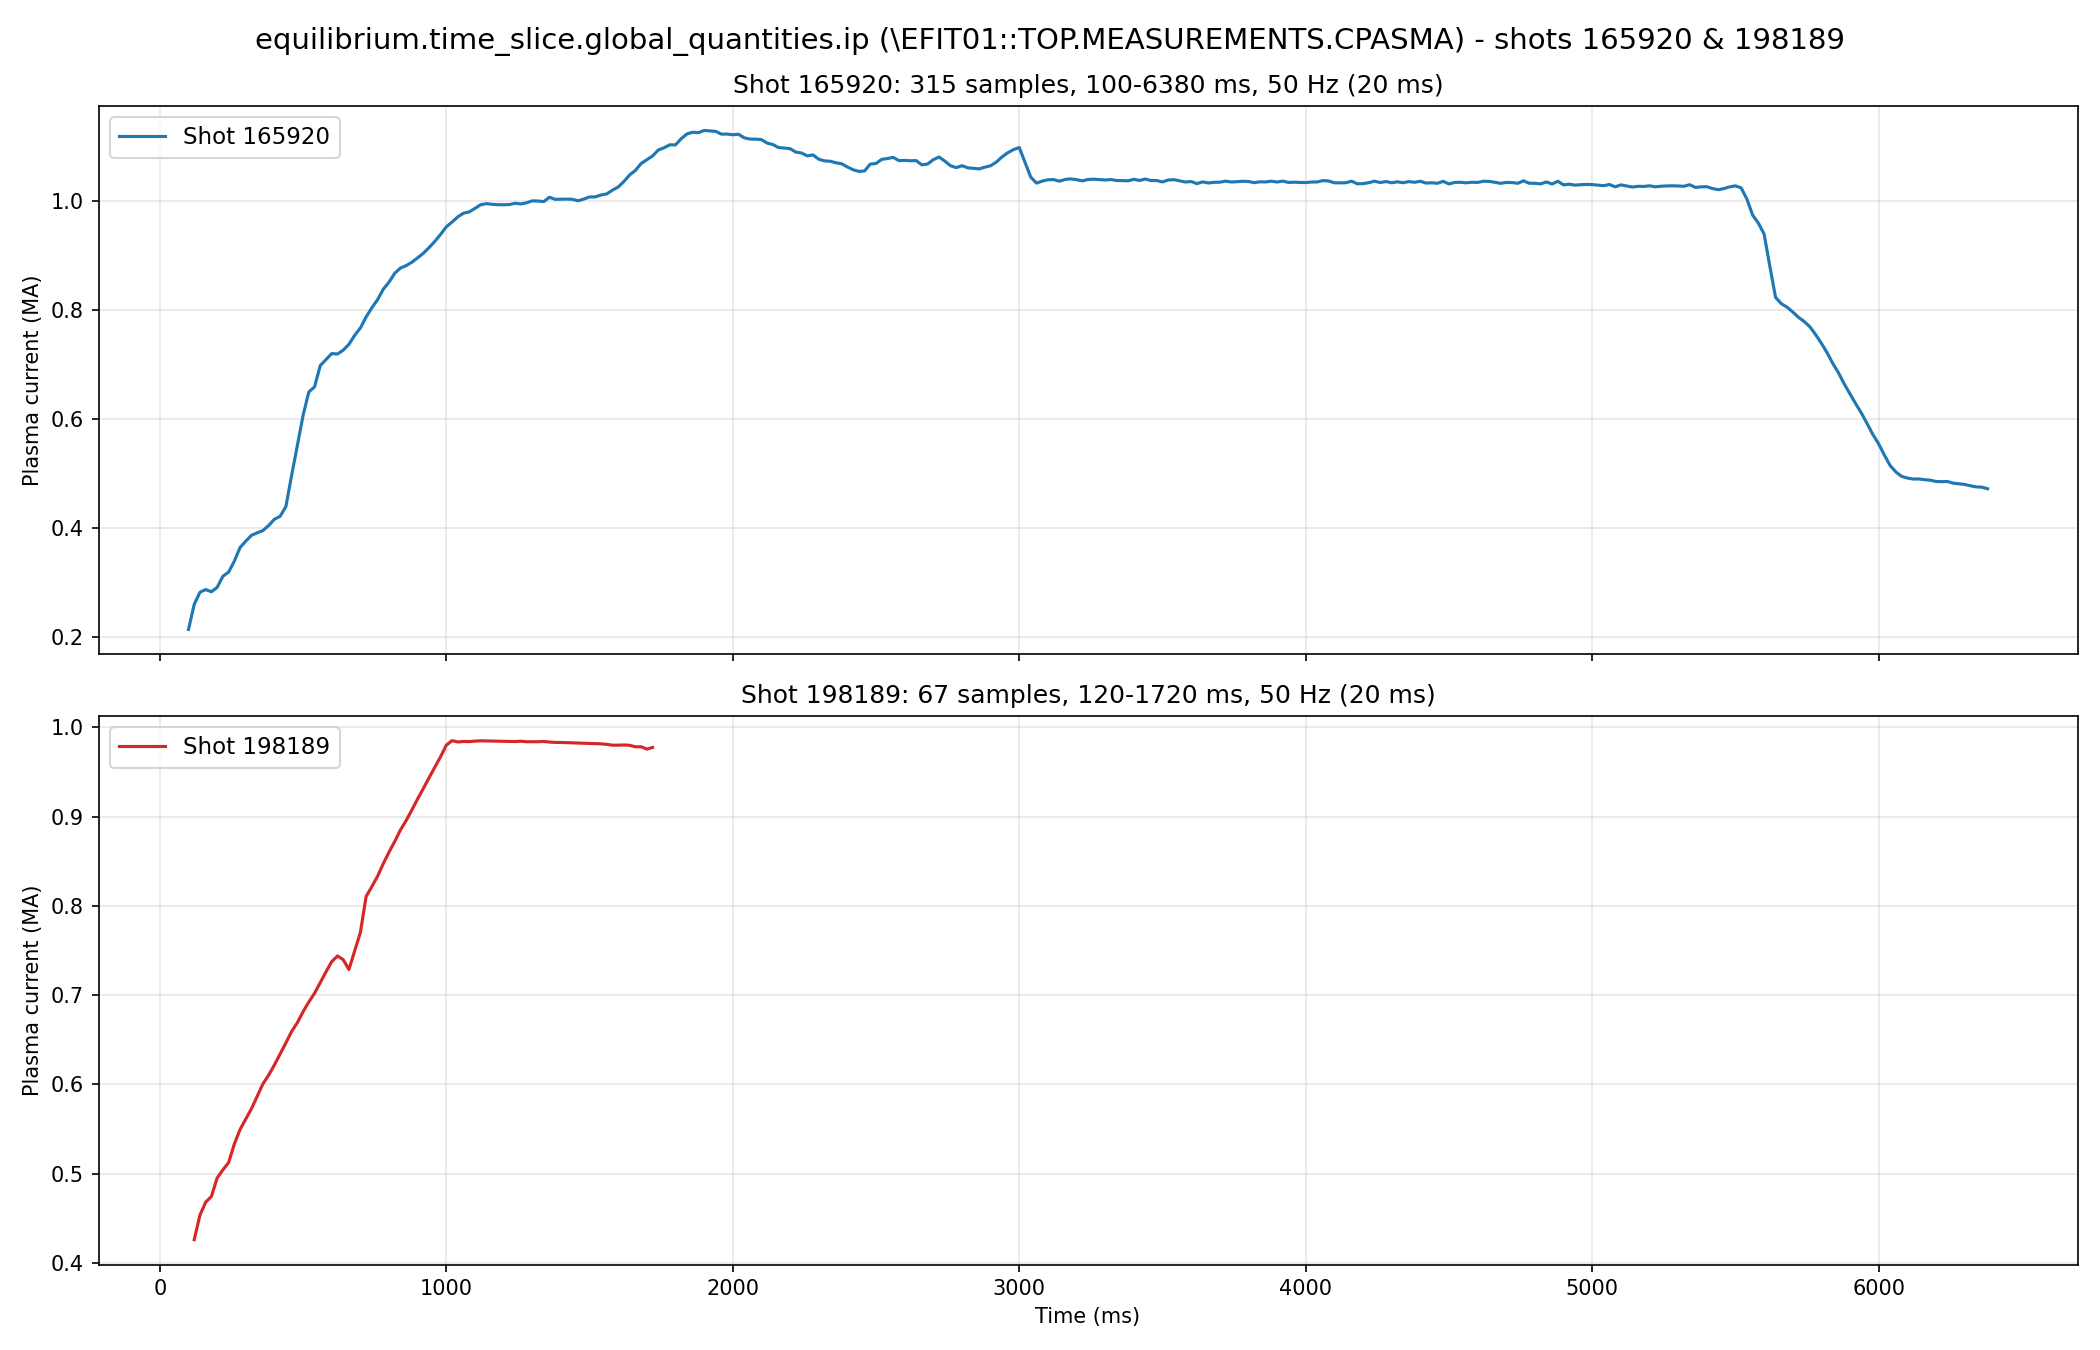

**Files saved** : `compare_ip_two_shots.png`, `ip_global_165920.csv`, `ip_global_198189.csv`.

**COCOS caution** : this field carries a **TOR** sign-convention transform — DIII-D and IMAS use different sign conventions for toroidal quantities including plasma current. The raw DIII-D values plotted here can be sign-flipped relative to the IMAS convention; magnitude and units are correct. Both traces are raw DIII-D values, so they're directly comparable to each other, but neither is guaranteed to match IMAS-standard sign without applying the transform.

In [19]:
%%ask
Fetch the IMAS plasma current for shots 165920 and 198189 and compare 
sampling rates

## 7. Mistyped input

Everything above assumes the user types an IMAS path correctly. These two
do not. A typo and a genuinely-absent field both fail to match exactly, so
without near-miss scoring they would produce the same confident "not in
the table" answer.

*Deliberate typo (`quantites`). A mistyped path and a genuinely absent one both fail to match, so the skill scores near-misses: this should be recovered, not reported as absent.*

In [20]:
%%ask
What is the DIII-D signal for equilibrium.time_slice.global_quantites.ip?

Reading the skill instructions to perform the lookup correctly.



The requested path contains a typo (`quantites` vs `quantities`) — exactly the case the skill's rule 1 covers. Running the lookup plus `suggest()` to confirm before answering.



The path you gave has a typo — `quantites` instead of `quantities`. The lookup returned `None` for the literal string, but `suggest()` scored the correct path at **similarity 0.994** (≥ 0.85 = almost certainly a typo), so I'm answering for the intended field and saying so explicitly.

## Did you mean `equilibrium.time_slice.global_quantities.ip`?

**DIII-D signal** : `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree `EFIT01`)

- **Fetch with** : `MdsSignal` (MDSplus tree `EFIT01`)
- **Verified** : yes — on shots 91388, 156199, 165920, 168442, 181681, 198189
- **Composed** : yes — built from **3 nodes** , not a single signal:
  - `\EFIT01::TOP.MEASUREMENTS.CPASMA` (the reconstructed plasma current)
  - `\EFIT01::TOP.RESULTS.GEQDSK.BCENTR` (toroidal field at center)
  - `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA` (GEQDSK CPASMA)
- **Confidence** : `derived` — resolved via the internal chain, not a direct node read
- **⚠️ COCOS caution** : this field carries a **TOR** sign-convention transform — DIII-D and IMAS use different sign conventions for toroidal quantities including plasma current. Serving the raw DIII-D value under this IMAS name can be **sign-flipped** (correct magnitude, correct units, wrong sign).

**Meaning** (per the row's provenance, not inferred from the name): this is the **reconstructed** plasma current from the EFIT equilibrium solve — upstream `_compose_ip_reconstructed` reads `MEASUREMENTS.CPASMA`. It is *not* the raw measured current (that's `equilibrium.time_slice.constraints.ip.measured` → `\EFIT01::TOP.MEASUREMENTS.PLASMA`), and it is *not* `\ipmhd` — the GEQDSK CPASMA node matches `\ipmhd` exactly, but the MEASUREMENTS CPASMA node this table maps does not.

*Deliberate typo (missing `_1d`) that lands on a field with **incomplete provenance**. The path served is the EFIT *time base*, not a flux array, because the real source is unresolved upstream — the answer should flag that rather than explain why it makes sense.*

In [21]:
%%ask
Which DIII-D signal backs core_profiles.profiles.grid.psi?

Reading the skill instructions to run the lookup correctly.



Running the lookup for `core_profiles.profiles.grid.psi` — note this path differs from the earlier `profiles_1d` question, so I'll check both the exact path and typo suggestions.



The exact path `core_profiles.profiles.grid.psi` is **not in the table** — but `suggest()` scored `core_profiles.profiles_1d.grid.psi` at **similarity 0.977** (≥ 0.85 = almost certainly a typo), so I'm answering for the intended field and saying so explicitly.

## Did you mean `core_profiles.profiles_1d.grid.psi`?

**⚠️ This field has no trustworthy DIII-D signal mapping.** The row exists but is flagged `resolution_partial: true`:

- **Path shown** : `\EFIT01::TOP.RESULTS.GEQDSK.GTIME` (tree `EFIT01`) — but this is the EFIT **time base** , not a poloidal-flux array
- **Why** : the field's real psi source (`core_profiles.profiles_1d._omfit_psi`) is in `unresolved_dependencies`; the row resolved via `core_profiles._gtime`, which is why GTIME appears
- **`caution_partial` verbatim** : "Provenance incomplete: this field's primary source could not be resolved, so the DIII-D path shown may be a secondary dependency (e.g. a time base), not the quantity itself. Do not present it as the mapping without checking upstream."
- **COCOS caution** : carries a **PSI** transform — sign convention differs between DIII-D and IMAS; serving a raw DIII-D value under this IMAS name can be sign-flipped
- **Verification** : `verified` on shots 91388, 156199, 165920, 168442, 181681, 198189 — but that only proves the GTIME node fetches, not that psi is available

**Bottom line** : do **not** fetch GTIME and call it psi. The table does not establish a DIII-D signal for this field.

## Related fields that DO resolve (offered as related, not as the answer)

| IMAS field | DIII-D signal | Notes |
|---|---|---|
| `equilibrium.time_slice.profiles_1d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIN` | Composed from 5 nodes (PSIN, SSIMAG, SSIBRY, BCENTR, CPASMA); PSI COCOS caution |
| `equilibrium.time_slice.profiles_2d.psi` | `\EFIT01::TOP.RESULTS.GEQDSK.PSIRZ` | Composed from 3 nodes (PSIRZ, BCENTR, CPASMA); PSI COCOS caution |

These are the equilibrium IDS psi fields — related quantities, **not** equivalent to the requested `core_profiles` grid psi.